### **Scroll all the way to the bottom for insights**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

train = pd.read_csv('train.csv')

print("Colunms:")
print(train.columns.tolist())

print("-"*30)
print("\nChurn value counts:")
print(train['Churn'].value_counts(dropna=False))
print("-"*30)
print("\nChurn value percentages:")
print(train['Churn'].value_counts(normalize=True, dropna=False)*100)


Colunms:
['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
------------------------------

Churn value counts:
Churn
No     460377
Yes    133817
Name: count, dtype: int64
------------------------------

Churn value percentages:
Churn
No     77.479241
Yes    22.520759
Name: proportion, dtype: float64


In [ ]:
total_charges = train['TotalCharges'].replace(r"^\s*$", np.nan, regex=True).astype(float)
train["TotalCharges_num"] = pd.to_numeric(total_charges, errors="coerce")

print("TotalCharges_num missing count:", train["TotalCharges"].isna().sum())
print("-"*30)
print(train[["tenure", "MonthlyCharges", "TotalCharges_num"]].describe())


TotalCharges_num missing count: 0
------------------------------
              tenure  MonthlyCharges  TotalCharges_num
count  594194.000000   594194.000000     594194.000000
mean       36.577258       65.866223       2494.377057
std        25.061922       31.067444       2353.916710
min         1.000000       18.250000         18.800000
25%        12.000000       29.900000        639.650000
50%        35.000000       74.100000       1433.650000
75%        62.000000       90.800000       4263.800000
max        72.000000      118.750000       8684.800000


   SeniorCitizen  proportion
0              0    0.885898
1              1    0.114102


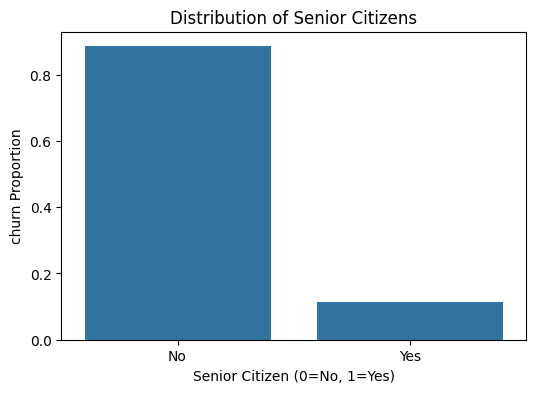

In [ ]:
# Senior Citizens distribution
plt.figure(figsize=(6,4))
sc_df = train['SeniorCitizen'].value_counts(normalize=True).reset_index()
print(sc_df)
sns.barplot(x='SeniorCitizen', y='proportion', data=sc_df)
plt.title('Distribution of Senior Citizens')
plt.xlabel('Senior Citizen (0=No, 1=Yes)')
plt.ylabel('churn Proportion')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()


### Senior Citizens churn rate Analysis

In [ ]:
# proportion of churners between senior citizens and non-senior citizens
train[train['Churn'] == 'Yes']['SeniorCitizen'].value_counts(normalize=True)


SeniorCitizen
0    0.746512
1    0.253488
Name: proportion, dtype: float64

   SeniorCitizen Churn  proportion
0              0    No    0.810226
1              0   Yes    0.189774
2              1   Yes    0.500317
3              1    No    0.499683


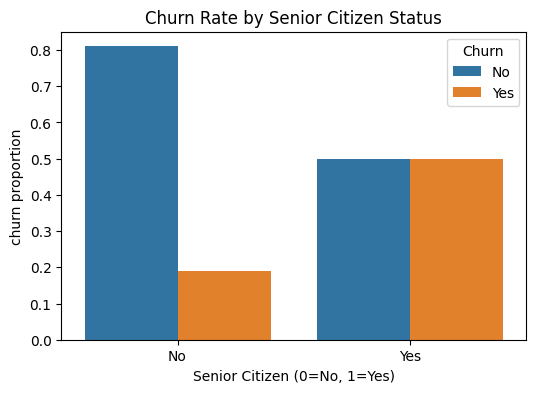

In [ ]:
# Senior Citizens churn rate
plt.figure(figsize=(6,4))
sc_churn_df = train.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).reset_index()
print(sc_churn_df)

sns.barplot(x='SeniorCitizen', y='proportion', hue='Churn', data=sc_churn_df)
plt.title('Churn Rate by Senior Citizen Status')
plt.xlabel('Senior Citizen (0=No, 1=Yes)')
plt.ylabel('churn proportion')
plt.xticks([0, 1], ['No', 'Yes'])
plt.legend(title='Churn')
plt.show()


### Partner and Dependents Analysis

In [90]:
seniors = train[train['SeniorCitizen'] == 1]

print(seniors.groupby('Partner')['Churn'].value_counts(normalize=True).unstack())
print("-"*30)
print(seniors.groupby('Dependents')['Churn'].value_counts(normalize=True).unstack())


Churn          No       Yes
Partner                    
No       0.396929  0.603071
Yes      0.609176  0.390824
------------------------------
Churn             No       Yes
Dependents                    
No          0.492213  0.507787
Yes         0.774679  0.225321


### Internet Service Provider Analysis For Senior Citizens

In [ ]:
print(train[train['Churn'] == 'Yes']['SeniorCitizen'].value_counts(normalize=True))


SeniorCitizen
0    0.746512
1    0.253488
Name: proportion, dtype: float64


InternetService  SeniorCitizen  Churn
DSL              0              No       0.903767
                                Yes      0.096233
                 1              No       0.758235
                                Yes      0.241765
Fiber optic      0              No       0.620711
                                Yes      0.379289
                 1              Yes      0.548871
                                No       0.451129
No               0              No       0.985980
                                Yes      0.014020
                 1              No       0.955588
                                Yes      0.044412
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Churn Rate: Internet Service vs Senior Citizen')

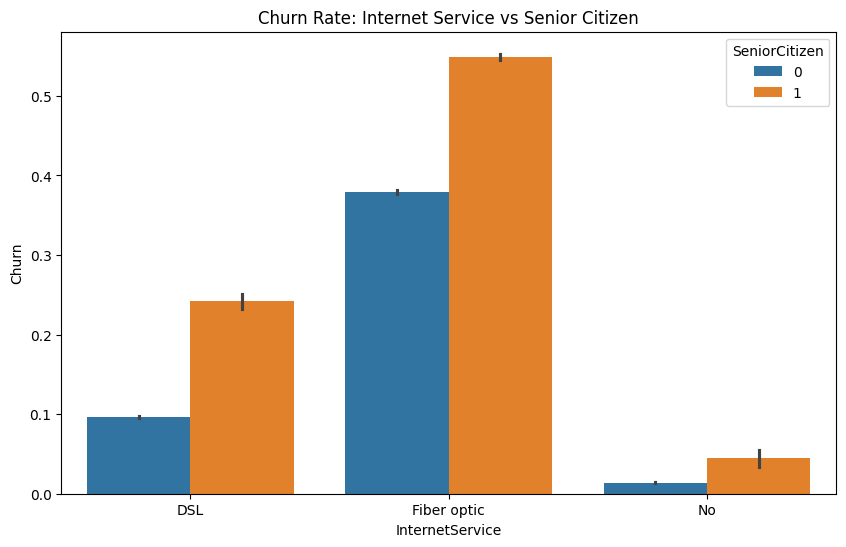

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print(train.groupby(['InternetService', 'SeniorCitizen'])['Churn'].value_counts(normalize=True))

# Interaction between Internet Service, Senior Citizen status, and Churn
plt.figure(figsize=(10,6))
sns.barplot(data=train, x='InternetService', y=train['Churn'].map({'No': 0, 'Yes': 1}), hue='SeniorCitizen')
plt.title("Churn Rate: Internet Service vs Senior Citizen")


### Service Quality Analysis For Senior Citizens

**(TechSupport, OnlineSecurity, OnlineBackup, DeviceProtection)**

TechSupport          SeniorCitizen  Churn
No                   0              No       0.637980
                                    Yes      0.362020
                     1              Yes      0.571599
                                    No       0.428401
No internet service  0              No       0.985980
                                    Yes      0.014020
                     1              No       0.955588
                                    Yes      0.044412
Yes                  0              No       0.913626
                                    Yes      0.086374
                     1              No       0.774031
                                    Yes      0.225969
Name: proportion, dtype: float64


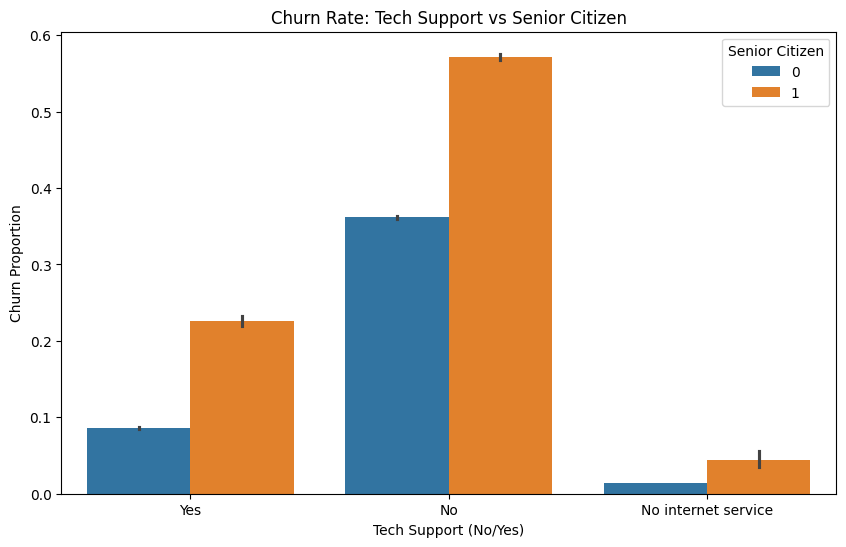

In [ ]:
# 1. Service Quality: TechSupport Analysis
print(train.groupby(['TechSupport', 'SeniorCitizen'])['Churn'].value_counts(normalize=True))
plt.figure(figsize=(10,6))
sns.barplot(data=train, x='TechSupport', y=train['Churn'].map({'No': 0, 'Yes': 1}), hue='SeniorCitizen')
plt.title("Churn Rate: Tech Support vs Senior Citizen")
plt.xlabel("Tech Support (No/Yes)")
plt.ylabel("Churn Proportion")
plt.legend(title='Senior Citizen')
plt.show()


OnlineSecurity       SeniorCitizen  Churn
No                   0              No       0.633471
                                    Yes      0.366529
                     1              Yes      0.577545
                                    No       0.422455
No internet service  0              No       0.985980
                                    Yes      0.014020
                     1              No       0.955588
                                    Yes      0.044412
Yes                  0              No       0.922601
                                    Yes      0.077399
                     1              No       0.795098
                                    Yes      0.204902
Name: proportion, dtype: float64


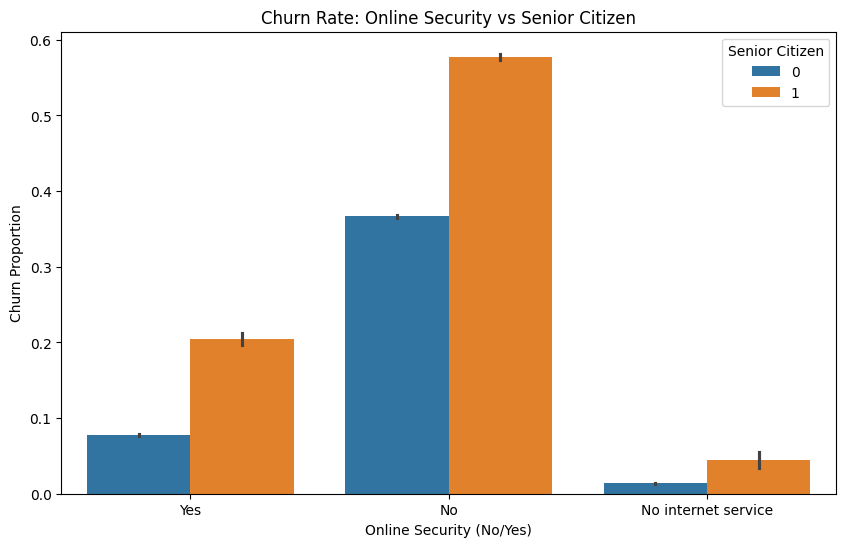

In [ ]:
# 1. Service Quality: OnlineSecurity Analysis
print(train.groupby(['OnlineSecurity', 'SeniorCitizen'])['Churn'].value_counts(normalize=True))
plt.figure(figsize=(10,6))
sns.barplot(data=train, x='OnlineSecurity', y=train['Churn'].map({'No': 0, 'Yes': 1}), hue='SeniorCitizen')
plt.title("Churn Rate: Online Security vs Senior Citizen")
plt.xlabel("Online Security (No/Yes)")
plt.ylabel("Churn Proportion")
plt.legend(title='Senior Citizen')
plt.show()


OnlineBackup         SeniorCitizen  Churn
No                   0              No       0.650761
                                    Yes      0.349239
                     1              Yes      0.603914
                                    No       0.396086
No internet service  0              No       0.985980
                                    Yes      0.014020
                     1              No       0.955588
                                    Yes      0.044412
Yes                  0              No       0.859898
                                    Yes      0.140102
                     1              No       0.642717
                                    Yes      0.357283
Name: proportion, dtype: float64


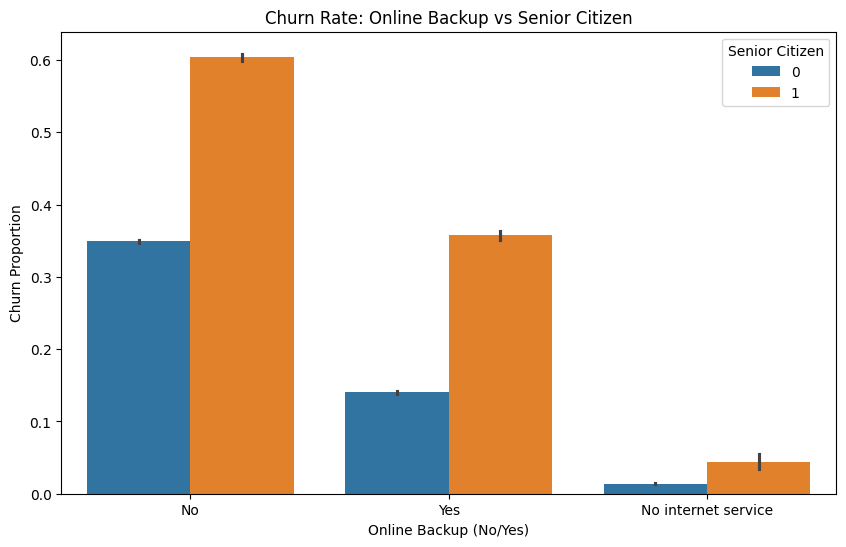

In [ ]:
# 1. Service Quality: OnlineBackup Analysis
print(train.groupby(['OnlineBackup', 'SeniorCitizen'])['Churn'].value_counts(normalize=True))
plt.figure(figsize=(10,6))
sns.barplot(data=train, x='OnlineBackup', y=train['Churn'].map({'No': 0, 'Yes': 1}), hue='SeniorCitizen')
plt.title("Churn Rate: Online Backup vs Senior Citizen")
plt.xlabel("Online Backup (No/Yes)")
plt.ylabel("Churn Proportion")
plt.legend(title='Senior Citizen')
plt.show()


DeviceProtection     SeniorCitizen  Churn
No                   0              No       0.660140
                                    Yes      0.339860
                     1              Yes      0.594407
                                    No       0.405593
No internet service  0              No       0.985980
                                    Yes      0.014020
                     1              No       0.955588
                                    Yes      0.044412
Yes                  0              No       0.847520
                                    Yes      0.152480
                     1              No       0.615686
                                    Yes      0.384314
Name: proportion, dtype: float64


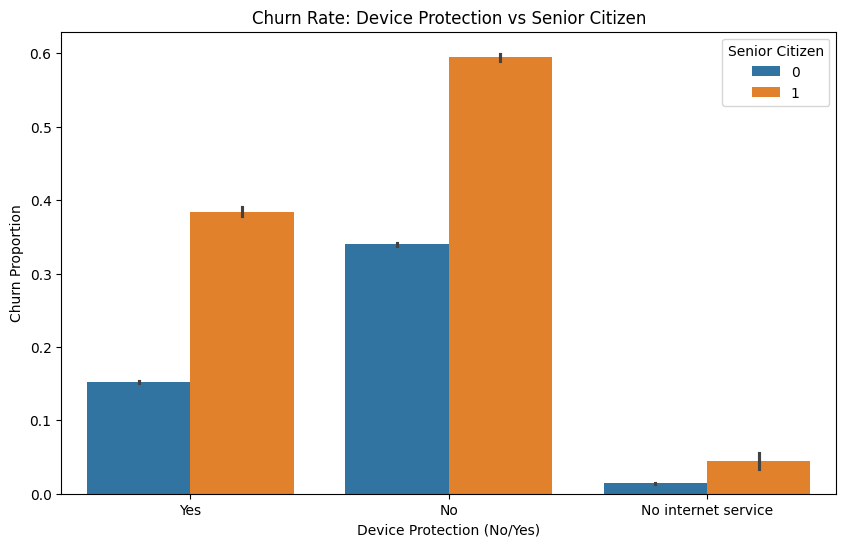

In [ ]:
# 1. Service Quality: DeviceProtection Analysis
print(train.groupby(['DeviceProtection', 'SeniorCitizen'])['Churn'].value_counts(normalize=True))
plt.figure(figsize=(10,6))
sns.barplot(data=train, x='DeviceProtection', y=train['Churn'].map({'No': 0, 'Yes': 1}), hue='SeniorCitizen')
plt.title("Churn Rate: Device Protection vs Senior Citizen")
plt.xlabel("Device Protection (No/Yes)")
plt.ylabel("Churn Proportion")
plt.legend(title='Senior Citizen')
plt.show()


### Churn-Tenure distribution of Senior Citizens

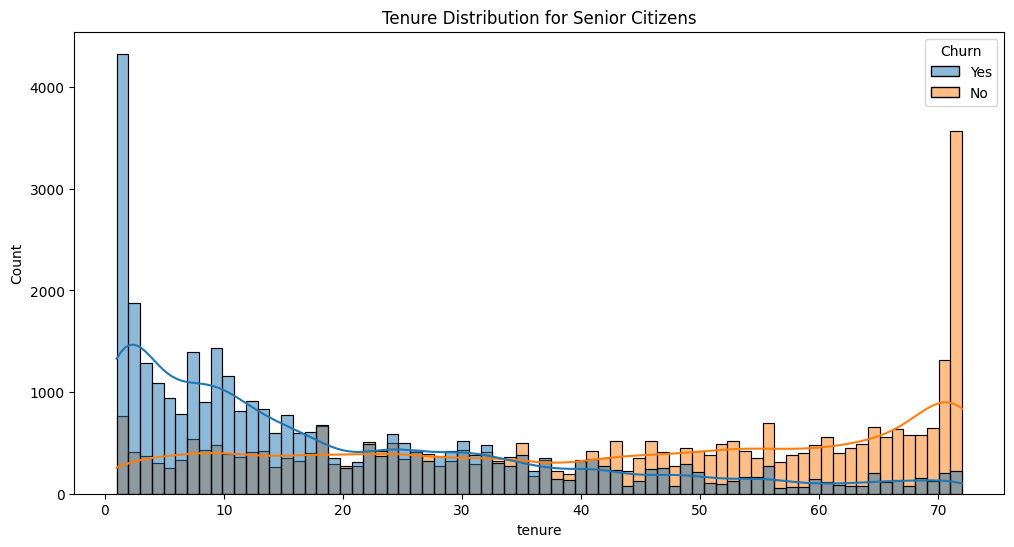

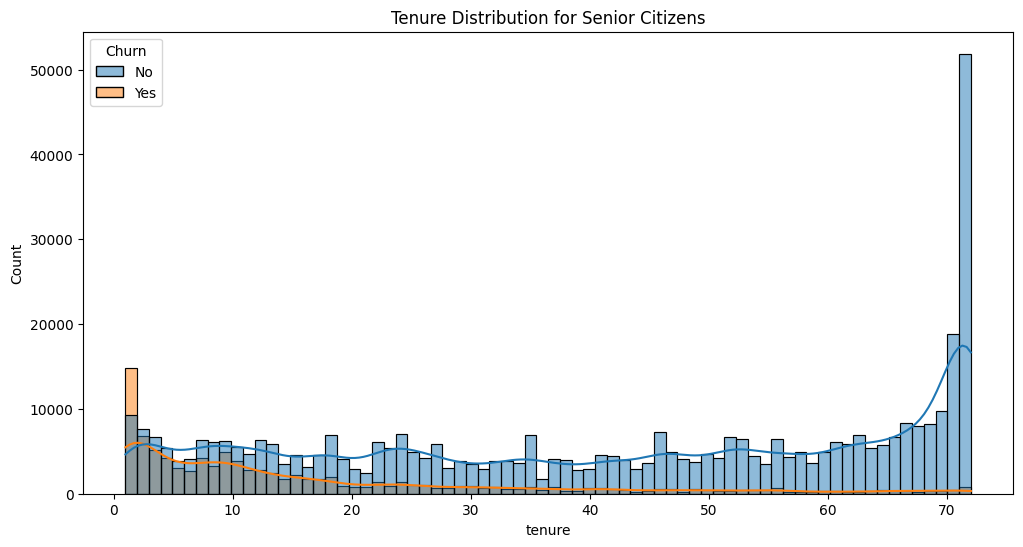

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(data=train[train['SeniorCitizen']==1], x='tenure', hue='Churn', kde=True, bins=72)
plt.title("Tenure Distribution for Senior Citizens")
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(data=train[train['SeniorCitizen']==0], x='tenure', hue='Churn', kde=True, bins=72)
plt.title("Tenure Distribution for Senior Citizens")
plt.show()


### Insight

Senior citizens make **11.41%** of the total customer base, but their churn rate is about **50.03%**, compared with **18.98%** for non-senior customers.

A separate statistic is that, among all churners, about **25.35%** are senior citizens and **74.65%** are non-seniors.

#### 1. InternetProvider
InternetProvider shows the same directional trends for both senior and non-senior customers, but senior citizens consistently have higher churn under the same service conditions.

#### 2. Senior Citizens Churn behaviour wrt. Partner
Among senior citizens, customers without a partner show a notably higher churn rate than those with a partner.

- **Churn if no partner:** 60.30%
- **Churn if partner:** 39.1%

This suggests that senior customers without a partner form a higher-risk retention segment and may require more targeted support or engagement strategies.

#### 3. Senior Citizens Churn behaviour wrt. Dependents
Among senior citizens, customers without dependents are significantly more likely to churn than those with dependents.

- **Churn if no dependents:** 50.8%
- **Churn if dependents:** 22.5%

By contrast, senior citizens with dependents are much more likely to stay, suggesting that family-linked households may be more stable and less prone to churn.

#### 4. Churn-Tenure distribution for Senior Citizens

The most dangerous churn window for the company is the early tenure period, especially the first ***1–6*** months. Customers who survive beyond that period, particularly into long tenure, appear much more stable.

#### Final Takeaway

Senior citizens form a relatively small share of the customer base, but they are a disproportionately high-risk churn segment. Their churn behaviour follows the same general patterns as non-seniors, but at a much worse level.

The clearest high-risk senior profile is a customer who:
- uses **Fiber Optic**
- lacks **Tech Support**, **Online Security**, or **Online Backup**
- has **no partner** or **no dependents**
- is in the **early tenure period**, especially the first **1–6 months**

This suggests that the senior segment is not uniformly risky. The real vulnerability is concentrated among seniors facing service friction, weak support coverage, and lower household stability.

A practical business recommendation is to prioritize early retention efforts for senior Fiber Optic customers, especially those without support/security services and those without partner/dependents. Bundled support-oriented services and stronger early-lifecycle engagement are likely to have the highest retention impact for this segment.
